In [31]:
!pip install -q kagglehub

In [32]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "brendan45774/bike-helmets-detection",
    output_dir="/content/helmet_dataset"
)

print(dataset_path)

Using Colab cache for faster access to the 'bike-helmets-detection' dataset.
/kaggle/input/bike-helmets-detection


In [33]:
import os

for root, dirs, files in os.walk("/content/helmet_dataset"):
    print(root)
    print("Folders:", dirs)
    print("Files:", files[:5])

/content/helmet_dataset
Folders: ['.complete', 'images', 'annotations']
Files: []
/content/helmet_dataset/.complete
Folders: ['datasets']
Files: []
/content/helmet_dataset/.complete/datasets
Folders: ['brendan45774']
Files: []
/content/helmet_dataset/.complete/datasets/brendan45774
Folders: ['bike-helmets-detection']
Files: []
/content/helmet_dataset/.complete/datasets/brendan45774/bike-helmets-detection
Folders: ['2']
Files: []
/content/helmet_dataset/.complete/datasets/brendan45774/bike-helmets-detection/2
Folders: []
Files: ['bundle.complete']
/content/helmet_dataset/images
Folders: []
Files: ['BikesHelmets641.png', 'BikesHelmets204.png', 'BikesHelmets650.png', 'BikesHelmets424.png', 'BikesHelmets649.png']
/content/helmet_dataset/annotations
Folders: []
Files: ['BikesHelmets646.xml', 'BikesHelmets148.xml', 'BikesHelmets597.xml', 'BikesHelmets540.xml', 'BikesHelmets217.xml']


In [34]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [35]:
import os
import cv2
import xml.etree.ElementTree as ET

images_dir = "/content/helmet_dataset/images"
annotations_dir = "/content/helmet_dataset/annotations"

output_dir = "/content/processed_helmet_dataset"

with_helmet_dir = os.path.join(output_dir, "with_helmet")
without_helmet_dir = os.path.join(output_dir, "without_helmet")

os.makedirs(with_helmet_dir, exist_ok=True)
os.makedirs(without_helmet_dir, exist_ok=True)

print("Images:", len(os.listdir(images_dir)))
print("Annotations:", len(os.listdir(annotations_dir)))

Images: 764
Annotations: 764


In [36]:
from collections import Counter

labels = Counter()

for xml_file in os.listdir(annotations_dir):

    if not xml_file.endswith(".xml"):
        continue

    xml_path = os.path.join(annotations_dir, xml_file)

    tree = ET.parse(xml_path)
    root = tree.getroot()

    for obj in root.findall("object"):

        name = obj.find("name")

        if name is not None:
            labels[name.text.strip()] += 1

print("Labels found:")
for label, count in labels.items():
    print(f"{label}: {count}")

Labels found:
With Helmet: 962
Without Helmet: 489


In [37]:
processed = 0
skipped = 0

for xml_file in os.listdir(annotations_dir):

    if not xml_file.endswith(".xml"):
        continue

    xml_path = os.path.join(annotations_dir, xml_file)

    # Read XML
    tree = ET.parse(xml_path)
    root = tree.getroot()

    # Get corresponding image name
    filename_element = root.find("filename")

    if filename_element is None:
        skipped += 1
        continue

    image_name = filename_element.text.strip()
    image_path = os.path.join(images_dir, image_name)

    # Check image
    if not os.path.exists(image_path):
        print("Missing image:", image_name)
        skipped += 1
        continue

    image = cv2.imread(image_path)

    if image is None:
        print("Could not read:", image_name)
        skipped += 1
        continue

    height, width = image.shape[:2]

    # Find all annotated objects
    objects = root.findall("object")

    for object_index, obj in enumerate(objects):

        name_element = obj.find("name")
        bbox = obj.find("bndbox")

        if name_element is None or bbox is None:
            continue

        label = name_element.text.strip().lower()

        # Convert slightly different spellings to standard names
        if label == "with helmet":
            save_dir = with_helmet_dir

        elif label == "without helmet":
            save_dir = without_helmet_dir

        else:
            print("Unknown label:", repr(label))
            continue

        # Bounding box
        xmin = int(float(bbox.find("xmin").text))
        ymin = int(float(bbox.find("ymin").text))
        xmax = int(float(bbox.find("xmax").text))
        ymax = int(float(bbox.find("ymax").text))

        # Keep coordinates inside image
        xmin = max(0, xmin)
        ymin = max(0, ymin)
        xmax = min(width, xmax)
        ymax = min(height, ymax)

        # Crop
        crop = image[ymin:ymax, xmin:xmax]

        if crop.size == 0:
            skipped += 1
            continue

        # Unique output filename
        base_name = os.path.splitext(image_name)[0]
        output_name = f"{base_name}_{object_index}.jpg"
        output_path = os.path.join(save_dir, output_name)

        cv2.imwrite(output_path, crop)

        processed += 1

print("\nPreprocessing complete!")
print("Processed:", processed)
print("Skipped:", skipped)


Preprocessing complete!
Processed: 1434
Skipped: 17


In [38]:
with_count = len(os.listdir(with_helmet_dir))
without_count = len(os.listdir(without_helmet_dir))

print("With helmet :", with_count)
print("Without helmet:", without_count)
print("Total:", with_count + without_count)

With helmet : 952
Without helmet: 482
Total: 1434


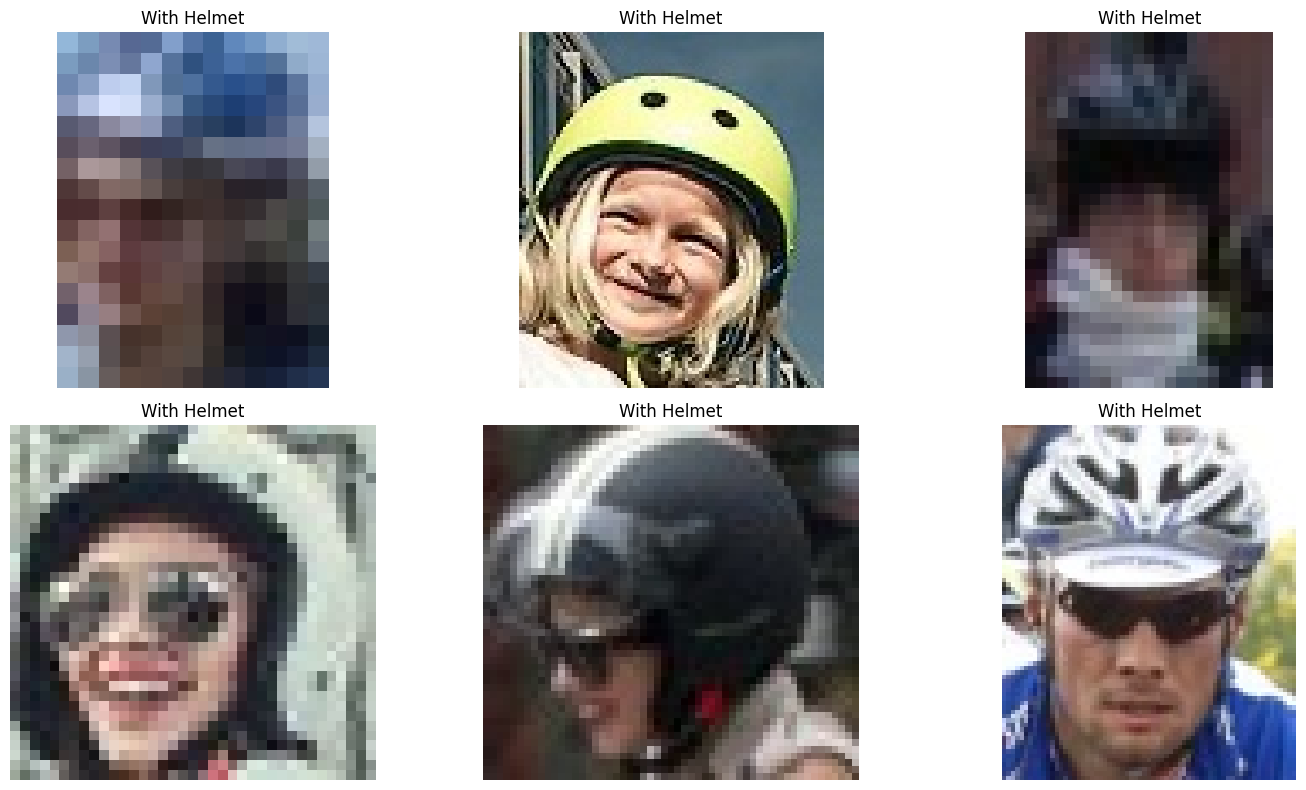

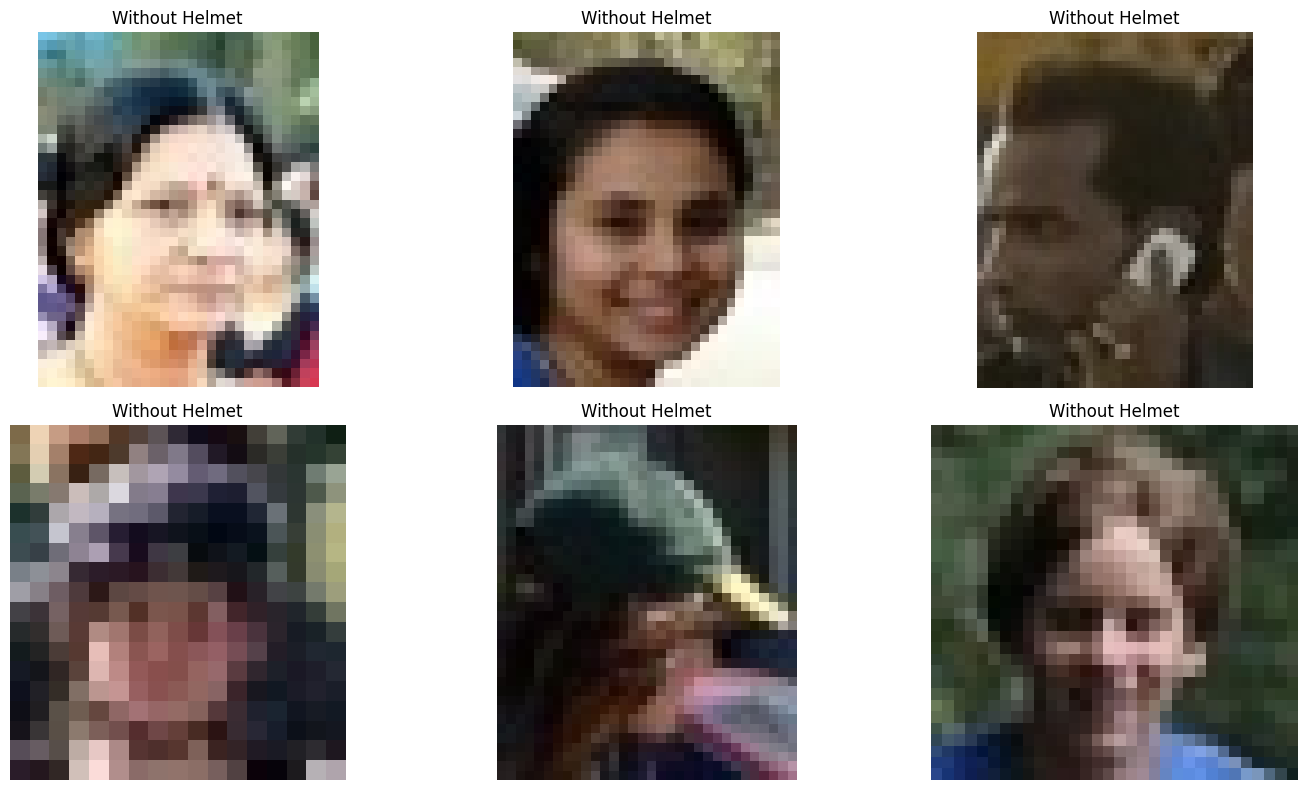

In [39]:
import matplotlib.pyplot as plt

def show_samples(folder, title, n=6):

    files = os.listdir(folder)[:n]

    plt.figure(figsize=(15, 8))

    for i, file in enumerate(files):

        image = cv2.imread(os.path.join(folder, file))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 3, i + 1)
        plt.imshow(image)
        plt.title(title)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_samples(with_helmet_dir, "With Helmet")
show_samples(without_helmet_dir, "Without Helmet")

In [40]:
import random
import shutil

random.seed(42)

split_base = "/content/helmet_split"

for split in ["train", "val", "test"]:
    for class_name in ["with_helmet", "without_helmet"]:
        os.makedirs(
            os.path.join(split_base, split, class_name),
            exist_ok=True
        )


In [41]:
for class_name, source_dir in [
    ("with_helmet", with_helmet_dir),
    ("without_helmet", without_helmet_dir)
]:

    files = [
        f for f in os.listdir(source_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    random.shuffle(files)

    total = len(files)

    train_end = int(0.70 * total)
    val_end = int(0.85 * total)

    train_files = files[:train_end]
    val_files = files[train_end:val_end]
    test_files = files[val_end:]

    for file in train_files:
        shutil.copy2(
            os.path.join(source_dir, file),
            os.path.join(split_base, "train", class_name, file)
        )

    for file in val_files:
        shutil.copy2(
            os.path.join(source_dir, file),
            os.path.join(split_base, "val", class_name, file)
        )

    for file in test_files:
        shutil.copy2(
            os.path.join(source_dir, file),
            os.path.join(split_base, "test", class_name, file)
        )

print("Dataset split complete!")

Dataset split complete!


In [42]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/helmet_split/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/helmet_split/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/helmet_split/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

print("Class names:", train_ds.class_names)

Found 1003 files belonging to 2 classes.
Found 215 files belonging to 2 classes.
Found 216 files belonging to 2 classes.
Class names: ['with_helmet', 'without_helmet']


In [43]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [44]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs, outputs)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [45]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [46]:
  callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )
]

In [47]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 222ms/step - accuracy: 0.5444 - loss: 0.7947 - val_accuracy: 0.6233 - val_loss: 0.6681
Epoch 2/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.5833 - loss: 0.7366 - val_accuracy: 0.6605 - val_loss: 0.6099
Epoch 3/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.6331 - loss: 0.6737 - val_accuracy: 0.7070 - val_loss: 0.5662
Epoch 4/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.6371 - loss: 0.6597 - val_accuracy: 0.7302 - val_loss: 0.5299
Epoch 5/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.6720 - loss: 0.6246 - val_accuracy: 0.7395 - val_loss: 0.5004
Epoch 6/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.6859 - loss: 0.5985 - val_accuracy: 0.7721 - val_loss: 0.4749
Epoch 7/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.7129 - loss: 0.5746 - val_accuracy: 0.7814 - val_loss: 0.4544
Epoch 8/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.7129 - loss: 0.5591 - val_accuracy: 0.7907 -

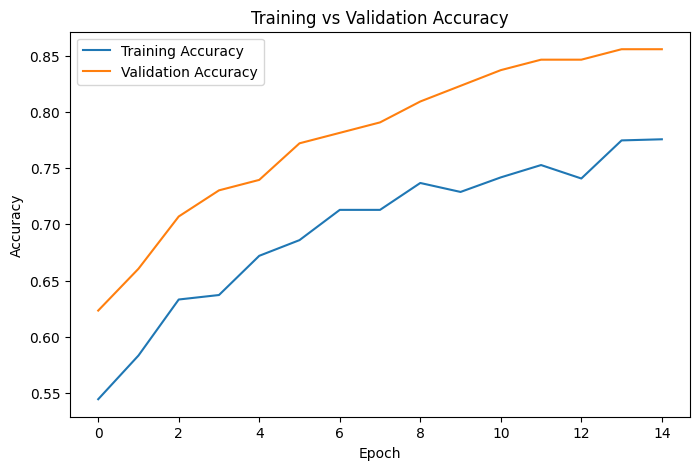

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

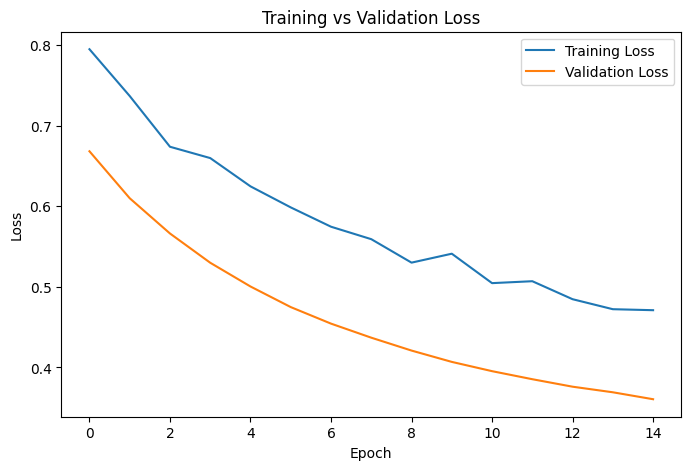

In [49]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [50]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.8426 - loss: 0.3891
Test Loss: 0.38905009627342224
Test Accuracy: 0.8425925970077515


In [51]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

In [52]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [53]:
fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 131ms/step - accuracy: 0.7637 - loss: 0.4969 - val_accuracy: 0.8605 - val_loss: 0.3335
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.7916 - loss: 0.4483 - val_accuracy: 0.8651 - val_loss: 0.3235
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.7986 - loss: 0.4237 - val_accuracy: 0.8651 - val_loss: 0.3126
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.8425 - loss: 0.3758 - val_accuracy: 0.8698 - val_loss: 0.3071
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.8375 - loss: 0.3644 - val_accuracy: 0.8651 - val_loss: 0.3006
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - accuracy: 0.8465 - loss: 0.3472 - val_accuracy: 0.8791 - val_loss: 0.2934
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - accuracy: 0.8495 - loss: 0.3476 - val_accuracy: 0.8837 - val_loss: 0.2781
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.8794 - loss: 0.3060 - val_accuracy: 0.8791 -

In [54]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Fine-tuned Test Accuracy:", test_accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8935 - loss: 0.2502
Fine-tuned Test Accuracy: 0.8935185074806213


In [55]:
model.save("/content/helmet_model.keras")

In [56]:
import os

print(os.path.getsize("/content/helmet_model.keras") / (1024 * 1024), "MB")

18.416662216186523 MB


In [57]:
from google.colab import files

files.download("/content/helmet_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [58]:
class_names = ["with_helmet", "without_helmet"]

import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0).ravel()

    y_true.extend(labels.numpy().astype(int))
    y_pred.extend((predictions >= 0.5).astype(int))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Class names:", class_names)

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

Class names: ['with_helmet', 'without_helmet']

Confusion Matrix:
[[126  17]
 [  6  67]]

Classification Report:
                precision    recall  f1-score   support

   with_helmet       0.95      0.88      0.92       143
without_helmet       0.80      0.92      0.85        73

      accuracy                           0.89       216
     macro avg       0.88      0.90      0.88       216
  weighted avg       0.90      0.89      0.90       216



/tmp/ipykernel_1351/923467264.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  true_label = class_names[int(labels[i].numpy())]


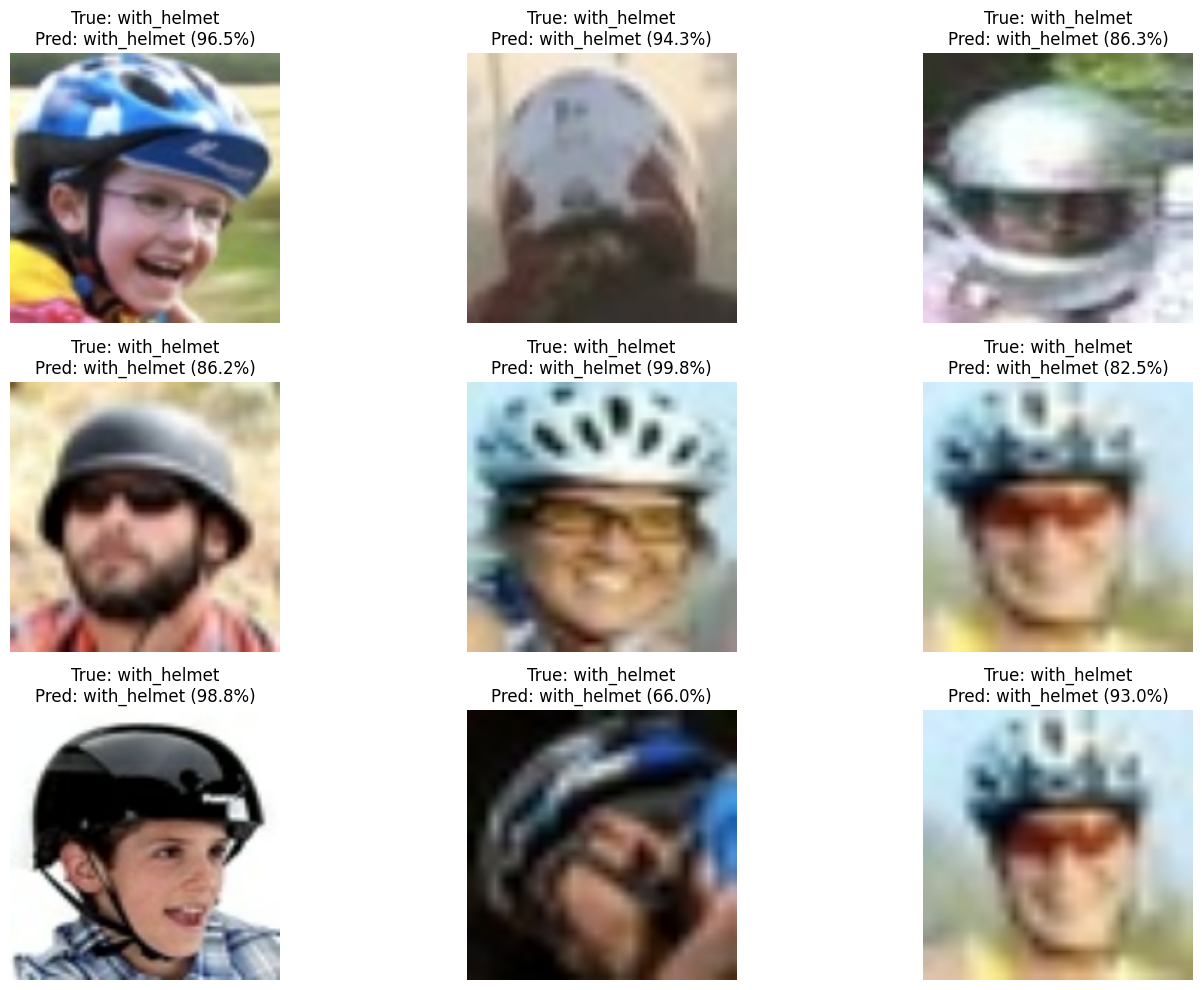

In [59]:
import matplotlib.pyplot as plt

for images, labels in test_ds.take(1):

    predictions = model.predict(images, verbose=0).ravel()

    plt.figure(figsize=(15, 10))

    for i in range(min(9, len(images))):

        image = images[i].numpy().astype("uint8")

        true_label = class_names[int(labels[i].numpy())]

        if predictions[i] >= 0.5:
            predicted_label = class_names[1]
            confidence = predictions[i]
        else:
            predicted_label = class_names[0]
            confidence = 1 - predictions[i]

        plt.subplot(3, 3, i + 1)
        plt.imshow(image)
        plt.title(
            f"True: {true_label}\n"
            f"Pred: {predicted_label} ({confidence*100:.1f}%)"
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()